In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import unumpy as unp
from uncertainties import ufloat
import math
from scipy.stats import linregress
from scipy.optimize import curve_fit
from IPython.display import Markdown, HTML, Latex, display

$$\text{Anna Lechner, Paula Erhard}$$

# PW12 - Mechanische Schwingungen

## Harmonische Schwingungen - Pendelschwingungen

### Versuchsaufbau und Durchführung



### Wichtige Formeln und Zusammenhänge



### Verwendete Geräte




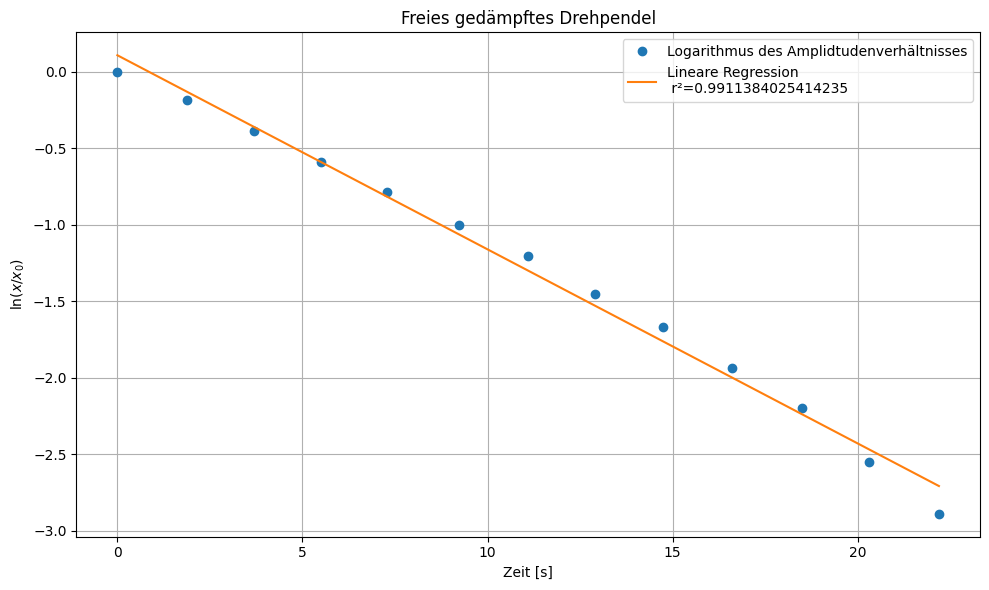

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

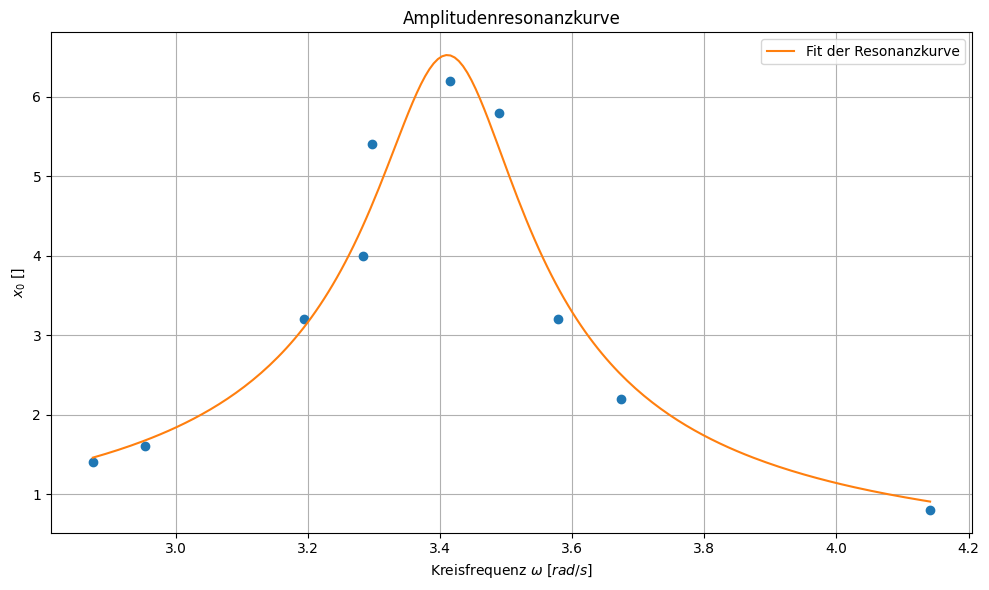

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [7]:
# 1. Experiment: Harmonische Schwingung

t = np.array([0, 1.88, 3.68, 5.49, 7.29, 9.23, 11.09, 12.89, 14.73, 16.59, 18.49, 20.29, 22.19])    #Zeit [s]
x = np.array([18, 15, 12.2, 10, 8.2, 6.6, 5.4, 4.2, 3.4, 2.6, 2, 1.4, 1])                           #Amplitude

# Dämpfungsstrom = 300mA

tu = unp.uarray(t, 0.2)     #mit Unsicherheit
xu = unp.uarray(x, 0.1)     #mit Unischerheit

T = t[-1]/len(t)        #Schwingungsdauer (Gesamtzeit durch Zahl der Schwingungen) [s]

w = 2*np.pi/ufloat(T,0.2)       #Kreisfrequenz [rad/s]

y = np.log(abs(x)/x[0])         #Logarithmus des amplituden Verhältnisses

res = linregress(t,y)

n= "\n"

#Plot
plt.figure(figsize=(10, 6))
plt.plot(t, y, "o", label="Logarithmus des Amplidtudenverhältnisses")
plt.plot(t, res.slope*t+res.intercept, "-", label=f"Lineare Regression {n} r²={res.rvalue**2}")
plt.ylabel(r"$\ln(x/x_0)$")
plt.xlabel(r"Zeit [s]")
plt.legend()
plt.title("Freies gedämpftes Drehpendel")
plt.tight_layout()
plt.grid()
plt.show()

display(Latex(fr"$$\omega_d = ({w:.2f}) ~ \mathrm rad/s$$"))      #Kreisfrquenz der gedämpften Schwingung [rad/s]

display(Latex(fr"$$\delta = ({abs(res.slope):.3f} \pm {res.stderr:.3f}) ~ \mathrm 1/s$$"))      #Dämpfungskonstante [1/s]

w0 = unp.sqrt(ufloat(abs(res.slope), res.stderr)**2 + w**2)     #Eigenfrequenz [rad/s]

display(Latex(fr"$$\omega_0 = ({w0:.3f}) ~ \mathrm rad/s$$"))                     #Eigenfrequenz [rad/s]

display(Latex(fr"$$Q_{{frei}} = {w0/(2*ufloat(abs(res.slope), res.stderr)):.3f}$$"))           #Gütefaktor freie Schwingung






# Getriebener 

w0 = unp.nominal_values(w0)         #Eigenfrequenz [rad/s] (wert von vorher ohne unsicherheit)


T = np.array([18.4, 18.01, 19.06, 15.17, 21.86, 21.28, 19.67, 19.14, 17.1, 17.56])/10       #Schwingungsdauer ? [s?]

f = 1/T             #frequenz [Hz]

x0 = np.array([6.2, 5.8, 5.4, 0.8, 1.4, 1.6, 3.2, 4, 2.2, 3.2])     #Amplituden

w = f * np.pi * 2       #Kreisfrequenz [rad/s]

w0 = w[0]

def resonanz(w, a, delta):          #fit funktion für resonanzkurve
    return (a) / np.sqrt((unp.nominal_values(w0)**2 - w**2)**2 + 4*(delta**2)*(w**2))

p0= [2, 0.1]            #anfangsdaten für fit

res, pcov = curve_fit(resonanz, w, x0, p0=p0)       #fit

a, delta_fit = res
a_err, delta_err = np.sqrt(np.diag(pcov))


w_fit = np.linspace(min(w),max(w),200)

plt.figure(figsize=(10, 6))
plt.plot(w, x0, "o")
plt.plot(w_fit,resonanz(w_fit, a, delta_fit), "-", label="Fit der Resonanzkurve")
plt.ylabel(r"$x_0$ $[]$")
plt.xlabel(r"Kreisfrequenz $\omega~[rad/s]$")
plt.legend()
plt.title("Amplitudenresonanzkurve")
plt.tight_layout()
plt.grid()
plt.show()


display(Latex(fr"$$\delta = ({delta_fit:.3f} \pm {delta_err:.3f}) ~ \mathrm 1/s$$"))        #Dämpfungskonstante [1/s]

display(Latex(fr"$$Q_{{erzwungen}} = {w0/(2*ufloat(delta_fit, delta_err)):.3f}$$"))         #GÜtefaktor

### Diskussion

## Gekoppelte Schwingungen

### Versuchsaufbau und Durchführung



### Wichtige Formeln und Zusammenhänge



### Verwendete Geräte




In [ ]:
# 2. Experiment: Gekoppelte Schwingungen

# Gleichsinnig

# L = (86 \pm 1)cm

# l = (49 \pm 1)cm


# w_gl = (1/17.72/10)*2*np.pi

# w_geg = (1/16.81/10)*2*np.pi


w_s = 1/(ufloat(32.95, 1))*np.pi        #werte eifnach messen i guess ?

w_2 = 1/(ufloat(8.67,1)/5)*2*np.pi


w1 = w_s + w_2

w0 = w_2 - w_s

K = 2*w_s*w_2/(w_2**2+w_s**2)


display(Latex(rf"$$\omega_s = {w_s:.4f}$$"))
display(Latex(rf"$$\omega_2 = {w_2:.2f}$$"))


# display(Latex(rf"$$\omega_{{gl}} = {w_gl:.2f}$$"))
# display(Latex(rf"$$\omega_{{geg}} = {w_geg:.2f}$$"))

display(Latex(rf"$$\omega_0 = {w0:.2f}$$"))
display(Latex(rf"$$\omega_1 = {w1:.2f}$$"))

display(Latex(rf"$$K = {K:.3f}$$"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Diskussion